<a href="https://colab.research.google.com/github/Carlosjara01/Inteligencia-Artificial/blob/main/Transformer_sentimiento_11052026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Sentimientos Multilingüe y Arquitectura de Transformers
Este cuaderno implementa un pipeline profesional de NLP utilizando **BETO** (Spanish BERT) y **DistilBERT**.

### Componentes Principales:
1. **Pipeline Multilingüe:** Inferencia optimizada.
2. **Arquitectura PyTorch:** Procesamiento por lotes y gestión de tensores.
3. **Teoría de Atención:** Simulación matemática de Scaled Dot-Product Attention.
4. **Configuración de Fine-tuning:** Definición de hiperparámetros profesionales.
5. **Visualización:** Análisis de curvas de aprendizaje y Early Stopping.

In [1]:
!pip install -q transformers torch matplotlib numpy

## 1. Simulación Matemática del Mecanismo de Atención (Q, K, V)
La atención permite al modelo enfocarse en partes específicas de la entrada. Se define como:
$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

In [2]:
import torch
import torch.nn.functional as F
import numpy as np

def simulate_attention(query_dim=64, seq_len=10):
    # Simulación de matrices Query, Key y Value
    Q = torch.randn(1, seq_len, query_dim)
    K = torch.randn(1, seq_len, query_dim)
    V = torch.randn(1, seq_len, query_dim)

    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(d_k)
    weights = F.softmax(scores, dim=-1)
    output = torch.matmul(weights, V)

    return weights, output

weights, output = simulate_attention()
print(f"Dimensiones de los pesos de atención: {weights.shape}")
print("Simulación completada.")

Dimensiones de los pesos de atención: torch.Size([1, 10, 10])
Simulación completada.


### Visualización de la Matriz de Atención
En un Transformer, la matriz de pesos de atención indica cuánto 'contexto' toma cada palabra de las demás. Vamos a visualizar la simulación anterior para ver las dependencias relacionales.

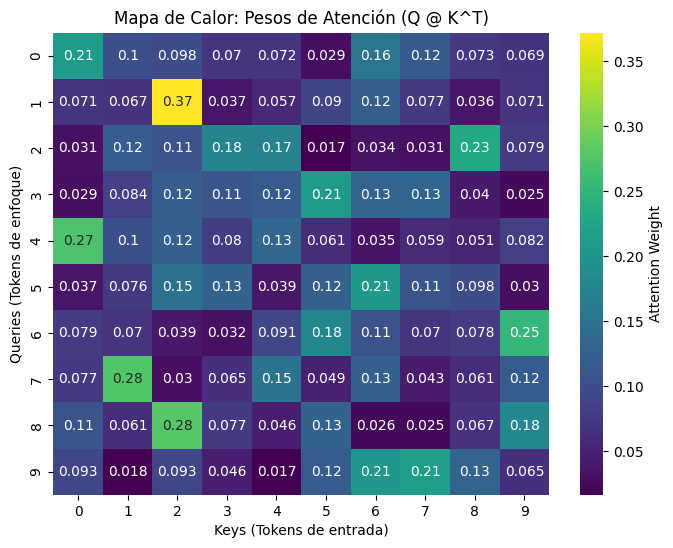

In [6]:
import seaborn as sns

def plot_attention_matrix(weights):
    # Tomamos el primer (y único) lote y cabezal de la simulación
    attn_data = weights[0].detach().numpy()

    plt.figure(figsize=(8, 6))
    sns.heatmap(attn_data, annot=True, cmap='viridis', cbar_kws={'label': 'Attention Weight'})
    plt.title("Mapa de Calor: Pesos de Atención (Q @ K^T)")
    plt.xlabel("Keys (Tokens de entrada)")
    plt.ylabel("Queries (Tokens de enfoque)")
    plt.show()

plot_attention_matrix(weights)

## 2. Configuración de Modelos y Procesamiento de Lotes

In [3]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

class SentimentAnalyzer:
    def __init__(self):
        # BETO para español, DistilBERT para inglés
        self.models = {
            'es': "dccuchile/bert-base-spanish-wwm-uncased",
            'en': "distilbert-base-uncased-finetuned-sst-2-english"
        }

    def process_batch(self, texts, lang='es'):
        pipe = pipeline("sentiment-analysis", model=self.models[lang])
        results = pipe(texts)

        # Uso de Tensores para separar resultados
        scores = torch.tensor([r['score'] for r in results])
        labels = [1 if r['label'] in ['POSITIVE', 'POS'] else 0 for r in results]
        labels_tensor = torch.tensor(labels)

        positives = scores[labels_tensor == 1]
        negatives = scores[labels_tensor == 0]

        return {"positives": positives, "negatives": negatives, "raw": results}

analyzer = SentimentAnalyzer()
# Prueba con frases ambiguas y culturales
texts_es = [
    "La película es una pasada, pero me dejó un sabor agridulce.",
    "No está mal, aunque esperaba algo más de chispa.",
    "¡Qué chulo el diseño, aunque el precio sea un robo!"
]

res = analyzer.process_batch(texts_es, lang='es')
print("Resultados de tensores positivos:", res['positives'])
print("Resultados de tensores negativos:", res['negatives'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Resultados de tensores positivos: tensor([])
Resultados de tensores negativos: tensor([0.5423, 0.5464, 0.5606])


## 3. Entorno de Fine-Tuning Profesional
Definición de hiperparámetros estándar para Transformers.

In [4]:
hyperparameters = {
    "learning_rate": 5e-5,
    "optimizer": "AdamW",
    "weight_decay": 0.01,
    "batch_size": 16,
    "epochs": 10,
    "early_stopping_patience": 3
}

print("Configuración de Fine-Tuning cargada:", hyperparameters)

Configuración de Fine-Tuning cargada: {'learning_rate': 5e-05, 'optimizer': 'AdamW', 'weight_decay': 0.01, 'batch_size': 16, 'epochs': 10, 'early_stopping_patience': 3}


## 4. Visualización Avanzada: Curvas de Entrenamiento y Early Stopping

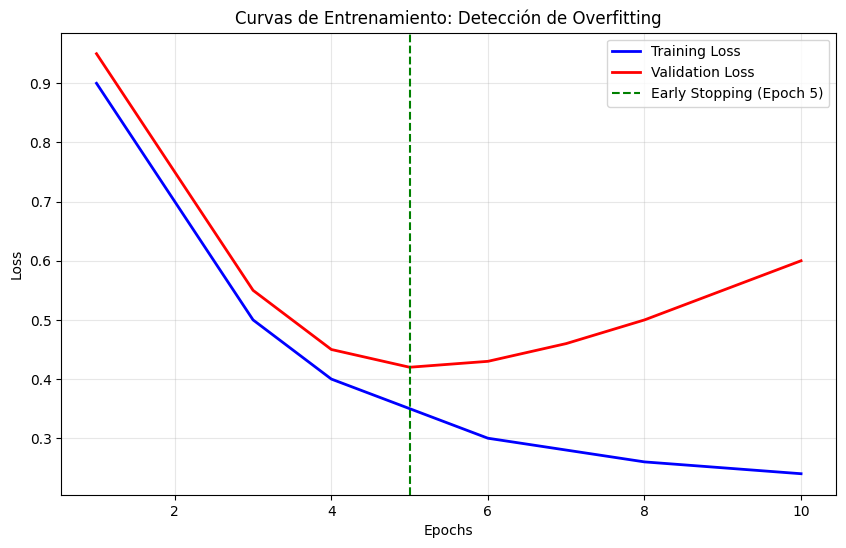

In [5]:
import matplotlib.pyplot as plt

def plot_training_dynamics():
    epochs = np.arange(1, 11)
    train_loss = [0.9, 0.7, 0.5, 0.4, 0.35, 0.3, 0.28, 0.26, 0.25, 0.24]
    val_loss = [0.95, 0.75, 0.55, 0.45, 0.42, 0.43, 0.46, 0.5, 0.55, 0.6]

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, label='Training Loss', color='blue', lw=2)
    plt.plot(epochs, val_loss, label='Validation Loss', color='red', lw=2)

    # Identificar Early Stopping (mínimo en val_loss)
    early_stop_epoch = np.argmin(val_loss) + 1
    plt.axvline(x=early_stop_epoch, linestyle='--', color='green', label=f'Early Stopping (Epoch {early_stop_epoch})')

    plt.title('Curvas de Entrenamiento: Detección de Overfitting')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_training_dynamics()